# Calibration Error Budget: How Well Must a Mueller Matrix Be Known to Measure Retardance?
_written by Jaren N. Ashcraft_

The [previous](BayesianPolarimetry.ipynb) [notebooks](OptimalPolarimeterDesign.ipynb) built and optimized a dual-rotating-retarder (DRRP) polarimeter. The *output* of such an instrument is a **measured Mueller matrix** $\mathbf{M}$ of a sample. A very common thing to do with $\mathbf{M}$ is to read off a scalar physical quantity — here, the sample's **total retardance**, via `katsu.mueller.retardance_from_mueller`:

$$\delta \;=\; \arccos\!\left(\tfrac{1}{2}\operatorname{tr}\mathbf{M}-1\right).$$

Every element of that measured Mueller matrix carries a **calibration uncertainty** — the DRRP is never perfectly calibrated, so each $M_{ij}$ is known only to some $\sigma_{ij}$. This notebook answers the **error-budget** (tolerancing) question:

> If I need the retardance to a precision $\sigma_\delta$ (say $0.1^\circ$), how well must each element $M_{ij}$ of the measured Mueller matrix be calibrated?

The tool is the **first-order (delta-method / Fisher) propagation** of the Mueller-element covariance $\boldsymbol{\Sigma}_M$ through the readout $\delta=f(\mathbf M)$:

$$\sigma_\delta^2 \;=\; \mathbf{g}^\top \boldsymbol{\Sigma}_M\, \mathbf{g},\qquad \mathbf{g}=\nabla_{\mathbf M}\, f\big|_{\mathbf M},$$

where $\mathbf g$ is the readout's sensitivity to each element (we get it exactly, for free, with `jax` autodiff). Requiring $\sigma_\delta\le$ target turns into a **per-element tolerance**. Equivalently, the calibration supplies an information matrix $\boldsymbol{\Sigma}_M^{-1}$ on the Mueller elements, and we ask how much information each element must carry to pin $\delta$ to target.

Finally we **verify** that the resulting retardance estimate really is Gaussian (so the linear budget is trustworthy) two ways: a Monte-Carlo push-forward through `retardance_from_mueller`, and a `blackjax` NUTS posterior.

In [2]:
from katsu.katsu_math import np, set_backend_to_jax
set_backend_to_jax()  # jax backend, before building anything

import jax
import blackjax
import scipy.stats as st
import matplotlib.pyplot as plt

from katsu.mueller import linear_retarder, retardance_from_mueller

## The measured Mueller matrix and its retardance readout

Our sample is a linear retarder with true retardance $\delta_\text{true}=90^\circ$ (a quarter-wave plate) at some fast-axis angle. A DRRP would report its Mueller matrix $\mathbf M$; feeding that to `retardance_from_mueller` returns the retardance. Note the readout is exact and **independent of the fast-axis angle** — because $\operatorname{tr}\mathbf M = 2+2\cos\delta$ for any pure retarder.

In [3]:
delta_true = np.radians(90.0)   # quarter-wave sample
axis = np.radians(20.0)         # fast-axis angle (arbitrary; readout doesn't depend on it)

M = linear_retarder(axis, delta_true)
print("measured Mueller matrix M:")
print(np.round(M, 4))
print(f"\nretardance_from_mueller(M) = {float(np.degrees(retardance_from_mueller(M))):.4f} deg")

measured Mueller matrix M:
[[ 1.      0.      0.      0.    ]
 [ 0.      0.5868  0.4924 -0.6428]
 [ 0.      0.4924  0.4132  0.766 ]
 [ 0.      0.6428 -0.766   0.    ]]

retardance_from_mueller(M) = 90.0000 deg


## Sensitivity of the readout to each Mueller element

The error budget is driven entirely by the gradient $\mathbf g=\partial\delta/\partial M_{ij}$. We obtain it exactly with `jax.jacrev` — no finite differences. Because $\delta$ depends on $\mathbf M$ **only through its trace**, this gradient has a clean analytic form:

$$\frac{\partial\delta}{\partial M_{ij}}=\begin{cases}-\dfrac{1}{2\sin\delta}, & i=j\\[2mm] 0,& i\neq j.\end{cases}$$

So only the **four diagonal elements** carry any sensitivity, they carry it **equally**, and every off-diagonal element is irrelevant to the total retardance. The overall scale $1/(2\sin\delta)$ already hints at the conditioning of the measurement.

autodiff diagonal sensitivity : 0.5000
analytic 1/(2 sin delta)      : 0.5000
max |off-diagonal sensitivity|: 0.00e+00


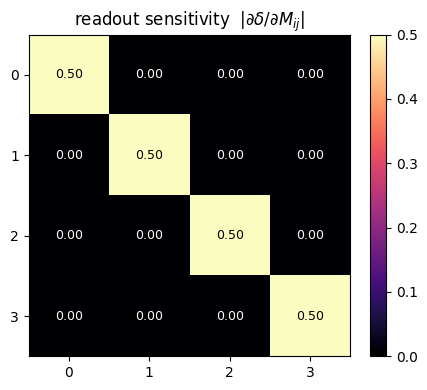

In [4]:
g = jax.jacrev(retardance_from_mueller)(M)   # 4x4 sensitivity matrix d(delta)/dM_ij

analytic = 1.0 / (2 * np.sin(delta_true))
print(f"autodiff diagonal sensitivity : {float(np.abs(g[0, 0])):.4f}")
print(f"analytic 1/(2 sin delta)      : {float(analytic):.4f}")
print(f"max |off-diagonal sensitivity|: {float(np.max(np.abs(g - np.diag(np.diag(g))))):.2e}")

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(np.abs(g), cmap="magma")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{float(np.abs(g[i, j])):.2f}", ha="center", va="center",
                color="w" if np.abs(g[i, j]) < 0.35 else "k", fontsize=9)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title(r"readout sensitivity  $|\partial\delta/\partial M_{ij}|$")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## From sensitivity to a per-element tolerance

Model the calibration errors as independent per element, $\boldsymbol{\Sigma}_M=\operatorname{diag}(\sigma_{ij}^2)$. Then

$$\sigma_\delta^2=\sum_{ij} g_{ij}^2\,\sigma_{ij}^2 .$$

There are two useful ways to turn a target $\sigma_\delta$ into element tolerances:

- **Sole-source** — if element $ij$ were the *only* error, it must satisfy $\sigma_{ij}\le \sigma_\delta/|g_{ij}|$.
- **Equal allocation** — split the variance budget evenly across the $K$ elements that actually matter: each is allowed $\sigma_\delta^2/K$, i.e. $\sigma_{ij}\le \sigma_\delta/(\sqrt{K}\,|g_{ij}|)$.

Here $K=4$ (the diagonal), $|g_{ij}|=1/(2\sin\delta)$, so the equal-allocation tolerance is simply $\sigma_{ij}\le\sigma_\delta\sin\delta$ on each diagonal element and **unconstrained** on every off-diagonal element.

target sigma_delta          : 0.100 deg
contributing elements (K)   : 4  (the diagonal)
diagonal tolerance (equal)  : 0.00175  (Mueller-element units)
diagonal tolerance (sole)   : 0.00349
off-diagonal tolerance      : unconstrained (infinite)

uniform diagonal calibration needed: sigma_cal = sigma_delta*sin(delta) = 0.00175


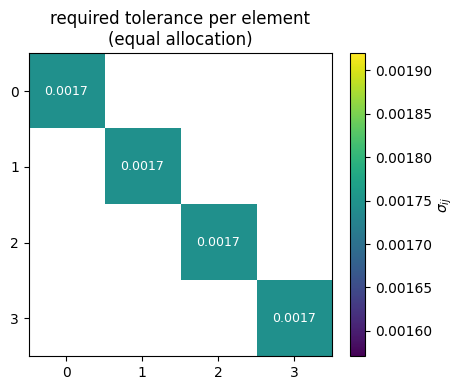

In [5]:
target_sigma_delta = np.radians(0.1)   # want retardance to 0.1 deg

absg = np.abs(g)
mask = absg > 1e-6                       # elements the readout actually depends on
K = int(np.sum(mask))

# Equal-allocation tolerance per element (inf where the readout is insensitive).
tol_equal = np.where(mask, target_sigma_delta / (np.sqrt(K) * np.where(mask, absg, 1.0)), np.inf)
tol_sole = np.where(mask, target_sigma_delta / np.where(mask, absg, 1.0), np.inf)

print(f"target sigma_delta          : {float(np.degrees(target_sigma_delta)):.3f} deg")
print(f"contributing elements (K)   : {K}  (the diagonal)")
print(f"diagonal tolerance (equal)  : {float(tol_equal[0, 0]):.5f}  (Mueller-element units)")
print(f"diagonal tolerance (sole)   : {float(tol_sole[0, 0]):.5f}")
print(f"off-diagonal tolerance      : unconstrained (infinite)")

# uniform-calibration view: if every diagonal element shares one precision sigma_cal,
# sigma_delta = ||g_diag|| sigma_cal = sigma_cal / sin(delta)  ->  sigma_cal = sigma_delta sin(delta)
sigma_cal = float(target_sigma_delta * np.sin(delta_true))
print(f"\nuniform diagonal calibration needed: sigma_cal = sigma_delta*sin(delta) = {sigma_cal:.5f}")

fig, ax = plt.subplots(figsize=(4.8, 4))
disp = np.where(mask, tol_equal, np.nan)
im = ax.imshow(disp, cmap="viridis")
for i in range(4):
    for j in range(4):
        txt = f"{float(tol_equal[i, j]):.4f}" if mask[i, j] else r"$\infty$"
        ax.text(j, i, txt, ha="center", va="center", color="w", fontsize=9)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title("required tolerance per element\n(equal allocation)")
fig.colorbar(im, ax=ax, fraction=0.046, label=r"$\sigma_{ij}$")
plt.tight_layout(); plt.show()

## Conditioning: retardance is easy at quarter-wave, hard near half-wave

The tolerance scales as $\sigma_{ij}\propto\sin\delta$, so the required calibration precision depends strongly on the retardance being measured. At $\delta=90^\circ$ ($\sin\delta=1$) the measurement is best-conditioned. As $\delta\to0$ or $\delta\to180^\circ$, $\sin\delta\to0$: the $\arccos$ readout flattens, the sensitivity $1/(2\sin\delta)$ blows up, and you would need an impossibly perfect Mueller matrix to hold $\sigma_\delta$. Near-zero and near-half-wave retarders are intrinsically hard to characterize.

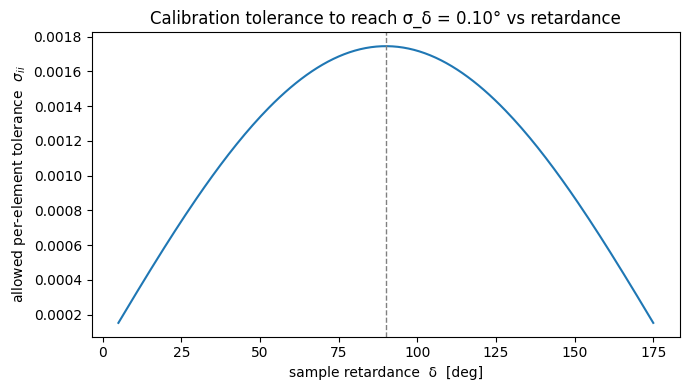

In [6]:
deltas = np.linspace(np.radians(5), np.radians(175), 200)
tol_vs_delta = target_sigma_delta * np.sin(deltas)   # equal-allocation diagonal tolerance

plt.figure(figsize=(7, 4))
plt.plot(np.degrees(deltas), tol_vs_delta)
plt.axvline(90, ls="--", color="gray", lw=1)
plt.xlabel("sample retardance  δ  [deg]")
plt.ylabel("allowed per-element tolerance  $\\sigma_{ii}$")
plt.title(f"Calibration tolerance to reach σ_δ = {float(np.degrees(target_sigma_delta)):.2f}° vs retardance")
plt.tight_layout(); plt.show()

## Verification 1 — Monte-Carlo push-forward through the readout

Is the linear (Gaussian) budget actually valid? The most direct check: perturb the Mueller matrix with the calibrated-to-tolerance noise $\mathcal N(0,\sigma_\text{cal}^2)$ on every element, push each noisy matrix through `retardance_from_mueller`, and look at the spread of the readout. If the budget is right, the histogram is Gaussian with width $\sigma_\delta=$ target.

predicted sigma_delta : 0.1000 deg
Monte-Carlo sigma     : 0.0995 deg
MC mean - delta_true  : +0.0003 deg
skewness / excess kurtosis : +0.003 / -0.034


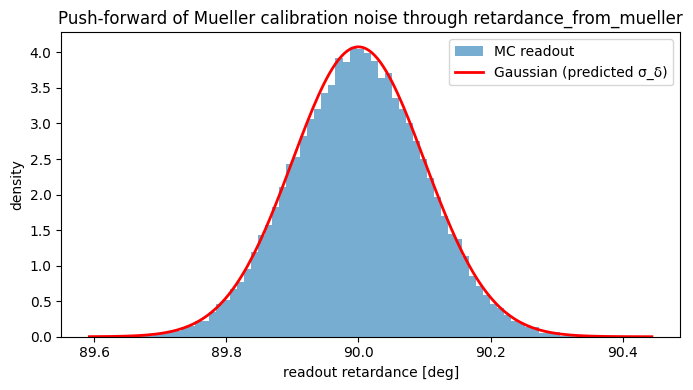

In [7]:
key = jax.random.PRNGKey(0)
n_mc = 40000
noise = jax.random.normal(key, (n_mc, 4, 4))
M_noisy = M[None] + sigma_cal * noise
delta_mc = retardance_from_mueller(M_noisy)

sigma_mc = float(np.degrees(np.std(delta_mc)))
print(f"predicted sigma_delta : {float(np.degrees(target_sigma_delta)):.4f} deg")
print(f"Monte-Carlo sigma     : {sigma_mc:.4f} deg")
print(f"MC mean - delta_true  : {float(np.degrees(np.mean(delta_mc) - delta_true)):+.4f} deg")
print(f"skewness / excess kurtosis : {float(st.skew(np.degrees(delta_mc))):+.3f} / {float(st.kurtosis(np.degrees(delta_mc))):+.3f}")

grid = np.linspace(delta_mc.min(), delta_mc.max(), 200)
gauss = np.exp(-0.5 * ((grid - delta_true) / target_sigma_delta) ** 2)
gauss = gauss / gauss.max()

plt.figure(figsize=(7, 4))
h, _, _ = plt.hist(np.degrees(delta_mc), bins=80, density=True, alpha=0.6, label="MC readout")
plt.plot(np.degrees(grid), gauss * h.max(), "r", lw=2, label="Gaussian (predicted σ_δ)")
plt.xlabel("readout retardance [deg]"); plt.ylabel("density")
plt.title("Push-forward of Mueller calibration noise through retardance_from_mueller")
plt.legend(); plt.tight_layout(); plt.show()

## Verification 2 — the Bayesian posterior with NUTS

Now the requested check: is the *posterior* over $\delta$ Gaussian? Because `retardance_from_mueller` depends on $\mathbf M$ only through the trace, the measured trace $T=\operatorname{tr}\mathbf M$ is the **sufficient statistic** for the retardance. We simulate one calibrated measurement, model $T\sim\mathcal N\!\big(2+2\cos\delta,\ (2\sigma_\text{cal})^2\big)$ (the trace sums four independent element errors), put a broad prior on $\delta$, and sample with `blackjax` NUTS.

In [8]:
key, nkey = jax.random.split(key)
M_obs = M + sigma_cal * jax.random.normal(nkey, (4, 4))
T_obs = np.trace(M_obs)

def log_posterior(p):
    d = p["delta"]
    trace_mean = 2.0 + 2.0 * np.cos(d)
    log_like = -0.5 * ((T_obs - trace_mean) / (2.0 * sigma_cal)) ** 2
    log_prior = -0.5 * ((d - np.pi / 2) / 0.5) ** 2   # broad, ~28 deg
    return log_like + log_prior

key, wkey = jax.random.split(key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_posterior, target_acceptance_rate=0.8)
(last_state, tuned), _ = warmup.run(wkey, {"delta": np.array(np.pi / 2)}, num_steps=500)
nuts = blackjax.nuts(log_posterior, **tuned)

def one_step(state, k):
    state, _ = nuts.step(k, state)
    return state, state.position["delta"]

key, skey = jax.random.split(key)
_, delta_samples = jax.lax.scan(one_step, last_state, jax.random.split(skey, 6000))
print(f"NUTS posterior: mean = {float(np.degrees(np.mean(delta_samples))):.4f} deg, "
      f"std = {float(np.degrees(np.std(delta_samples))):.4f} deg")
print(f"predicted σ_δ  = {float(np.degrees(target_sigma_delta)):.4f} deg")

NUTS posterior: mean = 90.0855 deg, std = 0.1004 deg
predicted σ_δ  = 0.1000 deg


A histogram of the posterior against the predicted Gaussian, plus a quantile-quantile plot, confirms the posterior is Gaussian with the width the error budget predicted. The Fisher/linear tolerancing is therefore trustworthy at this retardance and noise level.

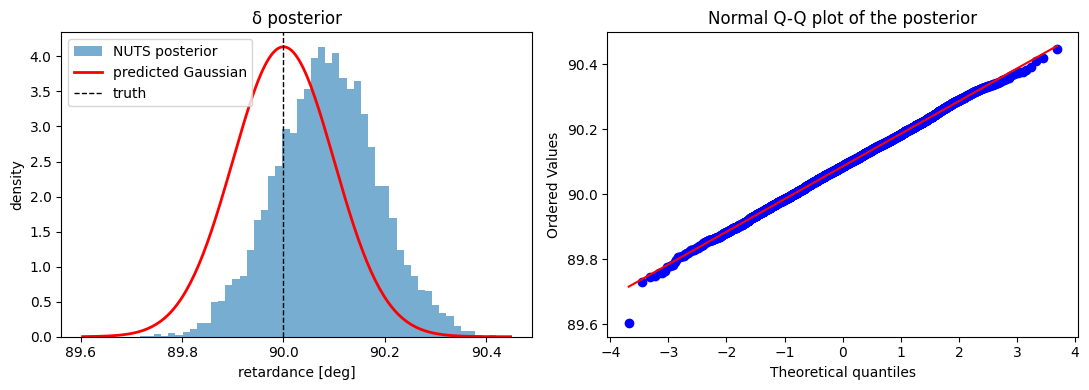

In [9]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))

grid = np.linspace(delta_samples.min(), delta_samples.max(), 200)
gauss = np.exp(-0.5 * ((grid - delta_true) / target_sigma_delta) ** 2)
h, _, _ = a0.hist(np.degrees(delta_samples), bins=60, density=True, alpha=0.6, label="NUTS posterior")
a0.plot(np.degrees(grid), gauss / gauss.max() * h.max(), "r", lw=2, label="predicted Gaussian")
a0.axvline(np.degrees(delta_true), ls="--", color="k", lw=1, label="truth")
a0.set_xlabel("retardance [deg]"); a0.set_ylabel("density"); a0.set_title("δ posterior"); a0.legend()

st.probplot(jax.device_get(np.degrees(delta_samples)), dist="norm", plot=a1)
a1.set_title("Normal Q-Q plot of the posterior")
plt.tight_layout(); plt.show()

## When the Gaussian budget breaks down

The linear budget is only as good as the Gaussian approximation of the readout, and it stays valid above only because we *shrank* $\sigma_\text{cal}$ in step with $\sin\delta$. Now hold the **calibration quality fixed** at the quarter-wave value and instead measure a near-half-wave sample. The $\arccos$ is steep and one-sided there, so the same element noise pushes through as a **skewed, wider-than-linear** retardance distribution, and a bias appears. Push a little further (beyond $\sim176^\circ$) and the noise can drive $\tfrac12\operatorname{tr}\mathbf M-1$ below $-1$, where $\arccos$ is undefined and the readout returns `NaN` outright — the measurement simply fails. This is the warning to sanity-check Gaussianity (and any Fisher/Laplace covariance) whenever a parameter sits near a boundary of its readout.

δ = 172° with the SAME σ_cal = 0.00175:
  linear-predicted σ_δ : 0.7185 deg
  Monte-Carlo σ        : 0.7319 deg
  MC mean - truth      : +0.0355 deg (bias)
  skewness             : +0.304


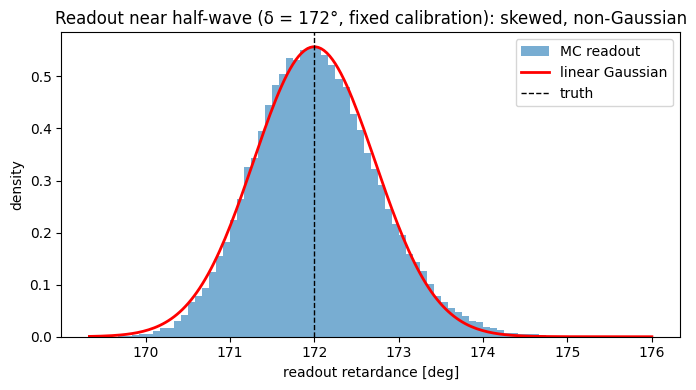

In [10]:
delta_hard = np.radians(172.0)
M_hard = linear_retarder(axis, delta_hard)
sigma_linear = sigma_cal / np.sin(delta_hard)   # naive linear prediction, calibration held fixed

key, hkey = jax.random.split(key)
M_noisy_hard = M_hard[None] + sigma_cal * jax.random.normal(hkey, (n_mc, 4, 4))
delta_hard_mc = retardance_from_mueller(M_noisy_hard)

print(f"δ = 172° with the SAME σ_cal = {sigma_cal:.5f}:")
print(f"  linear-predicted σ_δ : {float(np.degrees(sigma_linear)):.4f} deg")
print(f"  Monte-Carlo σ        : {float(np.degrees(np.std(delta_hard_mc))):.4f} deg")
print(f"  MC mean - truth      : {float(np.degrees(np.mean(delta_hard_mc) - delta_hard)):+.4f} deg (bias)")
print(f"  skewness             : {float(st.skew(np.degrees(delta_hard_mc))):+.3f}")

grid = np.linspace(delta_hard_mc.min(), delta_hard_mc.max(), 200)
gauss = np.exp(-0.5 * ((grid - delta_hard) / sigma_linear) ** 2)
plt.figure(figsize=(7, 4))
h, _, _ = plt.hist(np.degrees(delta_hard_mc), bins=80, density=True, alpha=0.6, label="MC readout")
plt.plot(np.degrees(grid), gauss / gauss.max() * h.max(), "r", lw=2, label="linear Gaussian")
plt.axvline(172.0, ls="--", color="k", lw=1, label="truth")
plt.xlabel("readout retardance [deg]"); plt.ylabel("density")
plt.title("Readout near half-wave (δ = 172°, fixed calibration): skewed, non-Gaussian")
plt.legend(); plt.tight_layout(); plt.show()

## Takeaways

- The total-retardance readout $\delta=\arccos(\tfrac12\operatorname{tr}\mathbf M-1)$ depends on the measured Mueller matrix **only through its trace**, so `jax` autodiff gives an exact, sparse sensitivity: **only the four diagonal elements need calibrating, equally, and every off-diagonal element is irrelevant.**
- Propagating a per-element calibration covariance with the Fisher/delta method turns a target $\sigma_\delta$ into concrete tolerances: to hit $0.1^\circ$ at quarter-wave, each diagonal element must be known to $\sigma_\delta\sin\delta\approx1.7\times10^{-3}$; off-diagonals are unconstrained.
- The tolerance scales as $\sin\delta$: quarter-wave retardances are easy, near-zero and near-half-wave retardances demand impractically perfect calibration.
- Monte-Carlo push-forward and a `blackjax` NUTS posterior both confirm the retardance estimate is Gaussian with exactly the predicted width at quarter-wave — but the same check reveals the budget breaking down (skew) near half-wave, a reminder to verify Gaussianity rather than assume it.